# Marginal Gaussianization via Inverse CDF

This notebook demonstrates how to use `MarginalGaussianize` from the new
`rbig` API to transform marginal distributions to a standard Gaussian via the
empirical CDF followed by the probit (Φ⁻¹) transform.

This "inverse-CDF Gaussianization" is the core marginal step inside each RBIG
layer.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns

from rbig import MarginalGaussianize

plt.style.use("seaborn-v0_8-paper")

/home/azureuser/localfiles/rbig/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data

We start from a **Uniform[0, 1]** distribution to cleanly illustrate the
inverse-CDF step: the empirical CDF of uniform data is approximately the
identity, so the probit transform maps it directly to N(0, 1).

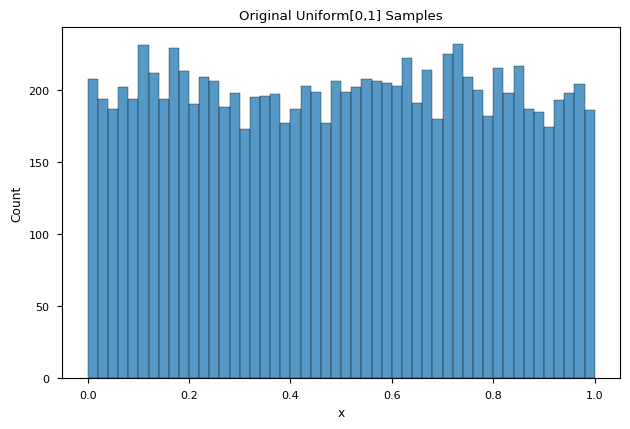

In [2]:
seed = 123
n_samples = 10_000

# Uniform distribution — easy to verify the Gaussianization analytically
data_dist = stats.uniform()
X = data_dist.rvs(size=(n_samples, 1), random_state=seed)

fig, ax = plt.subplots()
ax.set_title("Original Uniform[0,1] Samples")
sns.histplot(X[:, 0], ax=ax, bins=50)
ax.set_xlabel("x")
plt.tight_layout()
plt.show()

## MarginalGaussianize

`MarginalGaussianize` performs the following two-step transform **per feature**:

1. Map to uniform via empirical CDF: $u_i = \hat{F}(x_i)$
2. Apply the probit: $z_i = \Phi^{-1}(u_i)$

After fitting on training data the transform is applied to any new samples
sharing the same marginal distribution.

### Fit the model

In [3]:
marg_gauss = MarginalGaussianize(bound_correct=True, eps=1e-6)
marg_gauss.fit(X)

,bound_correct,True
,eps,1e-06


### Transform: original → Gaussian

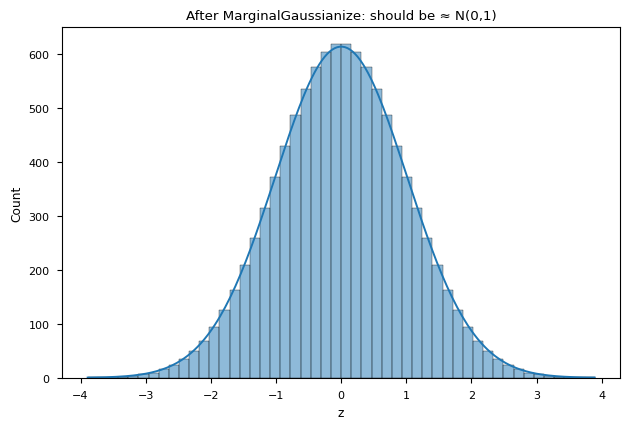

In [4]:
Xg = marg_gauss.transform(X)

fig, ax = plt.subplots()
ax.set_title("After MarginalGaussianize: should be ≈ N(0,1)")
sns.histplot(Xg[:, 0], ax=ax, bins=50, kde=True)
ax.set_xlabel("z")
plt.tight_layout()
plt.show()

### Inverse transform: Gaussian → original

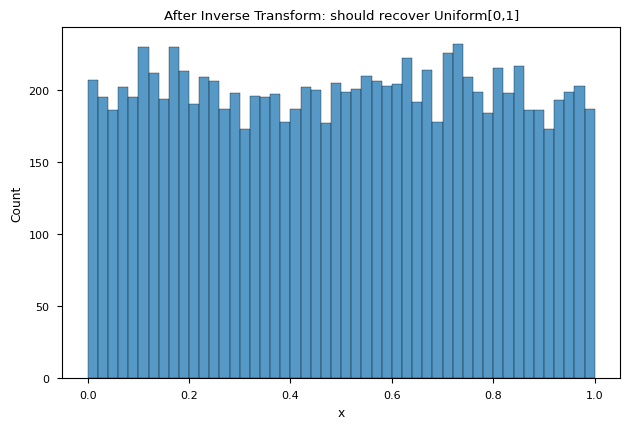

In [5]:
X_approx = marg_gauss.inverse_transform(Xg)

fig, ax = plt.subplots()
ax.set_title("After Inverse Transform: should recover Uniform[0,1]")
sns.histplot(X_approx[:, 0], ax=ax, bins=50)
ax.set_xlabel("x")
plt.tight_layout()
plt.show()

### Verify round-trip accuracy

In [6]:
residual = np.abs(X - X_approx).mean()
print(f"Mean absolute round-trip error: {residual:.4e}")

Mean absolute round-trip error: 2.4997e-05


### Log-determinant of the Jacobian

For normalizing flows and density estimation we need the log |det J| of the
transform.  `MarginalGaussianize` provides `log_det_jacobian(X)` which returns
a per-sample scalar (sum over features).

In [7]:
log_jac = marg_gauss.log_det_jacobian(X)
print(
    f"Log |det J|  — min: {log_jac.min():.3f}, max: {log_jac.max():.3f}, "
    f"mean: {log_jac.mean():.3f}"
)

Log |det J|  — min: -1.158, max: 10.997, mean: 2.005


## Generalisation: Skewed Distribution

Let us also apply `MarginalGaussianize` to a Gamma-distributed input to show
that it correctly handles non-symmetric distributions.

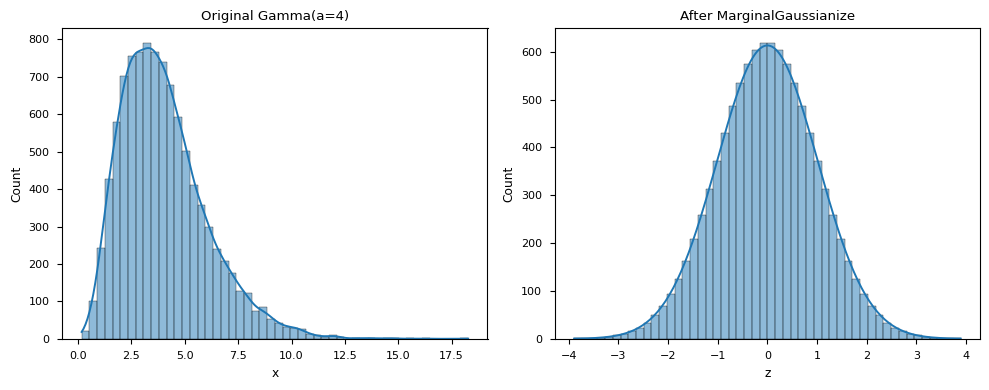

In [8]:
a = 4
data_gamma = stats.gamma(a=a)
X_gamma = data_gamma.rvs(size=(n_samples, 1), random_state=seed)

marg_gauss_gamma = MarginalGaussianize()
marg_gauss_gamma.fit(X_gamma)
Xg_gamma = marg_gauss_gamma.transform(X_gamma)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title(f"Original Gamma(a={a})")
sns.histplot(X_gamma[:, 0], ax=axes[0], bins=50, kde=True)
axes[0].set_xlabel("x")

axes[1].set_title("After MarginalGaussianize")
sns.histplot(Xg_gamma[:, 0], ax=axes[1], bins=50, kde=True)
axes[1].set_xlabel("z")

plt.tight_layout()
plt.show()

## Summary

`MarginalGaussianize` provides:

| Method | Description |
|---|---|
| `fit(X)` | Stores sorted support for each feature |
| `transform(X)` | Empirical CDF → probit → Gaussian |
| `inverse_transform(X)` | Gaussian → uniform CDF → original support |
| `log_det_jacobian(X)` | Per-sample log |det J| for density estimation |

This transform is the marginal step used inside every `RBIGLayer`.